<a href="https://colab.research.google.com/github/5556mani/AI-Engineering/blob/main/Pytorch/6_ANN_using_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [152]:
# import libraries
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as opt

In [153]:
df=pd.read_csv("fmnist_small.csv")

In [154]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [155]:
# setting seed
torch.manual_seed(42)

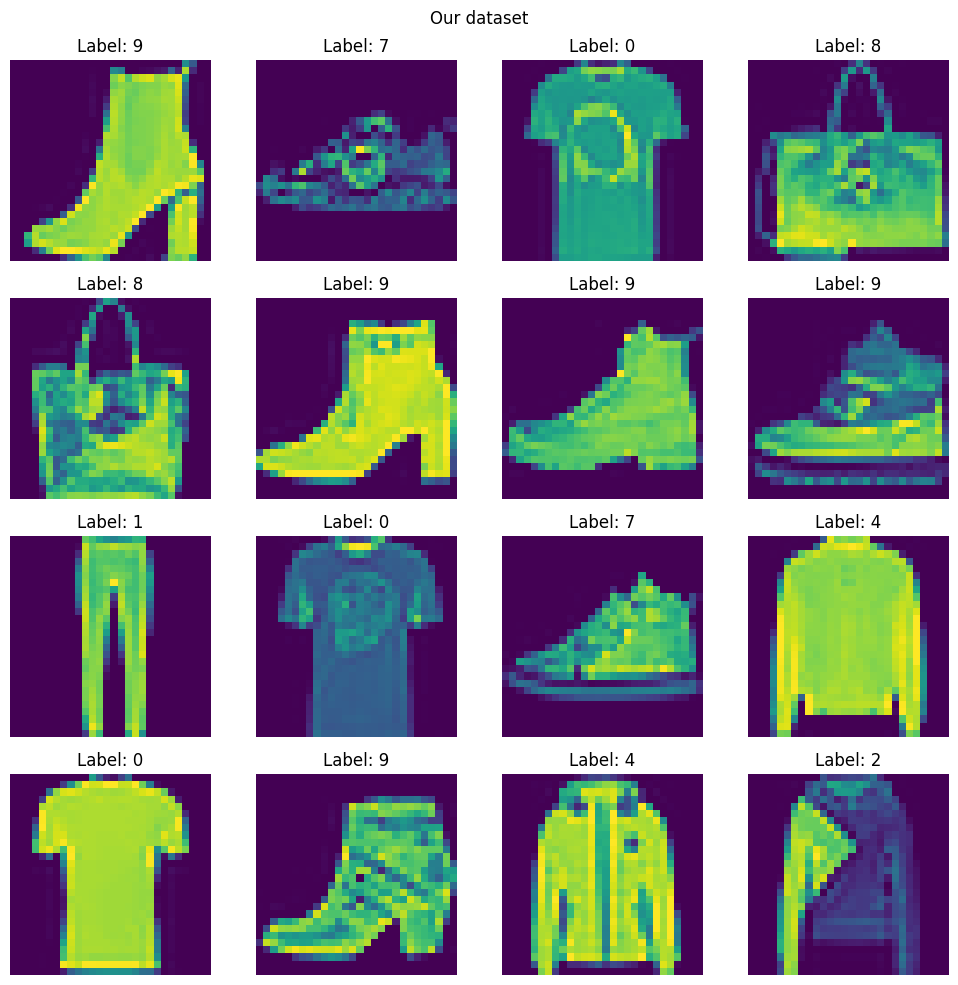

In [156]:
# see some of the figues

#create a grid of 4x4

fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("Our dataset")

for i,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout()
plt.show()

In [157]:
# splitting the dataset in train and test
X=df.iloc[:,1:].values
Y=df.iloc[:,0].values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [158]:
X_test=X_test/255.0
X_train=X_train/255.0

In [159]:
# writing custom class for dataset
class custom_DATA_class(Dataset):

  def __init__(self,features,labels):
    self.labels  =torch.tensor(labels,    dtype= torch.long)
    self.features=torch.tensor(features,  dtype= torch.float32  )

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]


In [160]:
# create train_dataset object
train_dataset=custom_DATA_class(X_train,Y_train)

In [161]:
plot_this=train_data[0][0].numpy()
plot_this=plot_this.reshape(28,28)

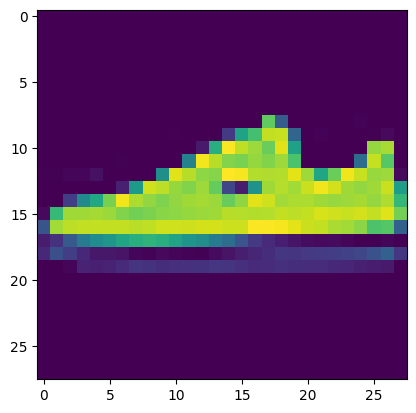

In [162]:
plt.imshow(plot_this)

In [163]:
# create test_dataset object
test_dataset = custom_DATA_class(X_test, Y_test)

In [171]:
# create Dataloader
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)

In [172]:
# define NN class
class NN(nn.Module):

  def __init__(self,inputshape):

    super().__init__()
    self.seq=nn.Sequential(
                          nn.Linear(inputshape,128),
                          nn.ReLU(),
                          nn.Linear(128,64),
                          nn.ReLU(),
                          nn.Linear(64,32),
                          nn.ReLU(),
                          nn.Linear(32,16),
                          nn.ReLU(),
                          nn.Linear(16,10)
    )


  def forward(self,features):
    return self.seq(features)

In [176]:
# hyperparameters
lr=0.03
epochs=200

In [177]:
 # model , loss function , optimiser
 model=NN(X_train.shape[1])

 loss_func=nn.CrossEntropyLoss()

 optim=opt.SGD(model.parameters(), lr=lr, momentum=0.9)

In [178]:
# training loop
for epoch in range(epochs):
  epoch_loss=0
  for batch_features,batch_labels in train_loader:

    #forward pass
    out=model(batch_features)

    # loss
    loss=loss_func(out,batch_labels)

    # back-propogation
    optim.zero_grad()
    loss.backward()

    #update
    optim.step()

    epoch_loss+=loss.item()
  avg_l=epoch_loss/len(train_loader)
  print(f"Epoch: {epoch+1}, Loss: {avg_l}")

Epoch: 1, Loss: 1.7643698914845785
Epoch: 2, Loss: 0.8760968361298244
Epoch: 3, Loss: 0.7354890042543412
Epoch: 4, Loss: 0.6698888609806697
Epoch: 5, Loss: 0.6211544173955917
Epoch: 6, Loss: 0.5517419819037119
Epoch: 7, Loss: 0.517533744374911
Epoch: 8, Loss: 0.48844042350848516
Epoch: 9, Loss: 0.4825370875994364
Epoch: 10, Loss: 0.43232366899649305
Epoch: 11, Loss: 0.4471237603326639
Epoch: 12, Loss: 0.4334279751777649
Epoch: 13, Loss: 0.3792132656276226
Epoch: 14, Loss: 0.41881117631991704
Epoch: 15, Loss: 0.4061946711937586
Epoch: 16, Loss: 0.36506352727611857
Epoch: 17, Loss: 0.36974721079071365
Epoch: 18, Loss: 0.34060937613248826
Epoch: 19, Loss: 0.361803526977698
Epoch: 20, Loss: 0.32846790984272956
Epoch: 21, Loss: 0.30641656011343005
Epoch: 22, Loss: 0.30936703766385715
Epoch: 23, Loss: 0.3014592762788137
Epoch: 24, Loss: 0.31256372774640717
Epoch: 25, Loss: 0.3041024420410395
Epoch: 26, Loss: 0.29860570684075355
Epoch: 27, Loss: 0.3128538424273332
Epoch: 28, Loss: 0.297204501

In [179]:
# eval mode
model.eval()

NN(
  (seq): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=10, bias=True)
  )
)

In [180]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.8225
